# Fraud Senario 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
customer_profiles = pd.read_csv('full dataset with brief/customer_profiles.csv')
fraudulent_transactions = pd.read_csv('full dataset with brief/synthetic_fraud_transactions.csv')
terminal_profiles = pd.read_csv('full dataset with brief/terminal_profiles.csv')

In [3]:
customer_profiles.head()

,CUSTOMER_ID,x_customer_id,y_customer_id,mean_amount,std_amount,mean_nb_tx_per_day,nb_terminals
0,0,54.881350,71.518937,62.262521,31.131260,2.179533,78
1,1,42.365480,64.589411,46.570785,23.285393,3.567092,85
2,2,96.366276,38.344152,80.213879,40.106939,2.115580,70
3,3,56.804456,92.559664,11.748426,5.874213,0.348517,70
4,4,2.021840,83.261985,78.924891,39.462446,3.480049,65


In [4]:
fraudulent_transactions.head()

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO
0,0,2018-04-01 00:00:31,596,3156,57.16,31,0,0,0
1,1,2018-04-01 00:02:10,4961,3412,81.51,130,0,0,0
2,2,2018-04-01 00:07:56,2,1365,146.00,476,0,0,0
3,3,2018-04-01 00:09:29,4128,8737,64.49,569,0,0,0
4,4,2018-04-01 00:10:34,927,9906,50.99,634,0,0,0


In [5]:
terminal_profiles.head()

,TERMINAL_ID,x_terminal_id,y_terminal_id
0,0,41.702200,72.032449
1,1,0.011437,30.233257
2,2,14.675589,9.233859
3,3,18.626021,34.556073
4,4,39.676747,53.881673


In [6]:
# make inner join between customer_profiles and fraudulent_transactions on 'customer_id'
merged_df = pd.merge(customer_profiles, fraudulent_transactions, on='CUSTOMER_ID', how='inner')

In [7]:
copy_merged_df = merged_df.copy()

### Inspect Data

In [8]:
copy_merged_df.head()

,CUSTOMER_ID,x_customer_id,y_customer_id,mean_amount,std_amount,mean_nb_tx_per_day,nb_terminals,TRANSACTION_ID,TX_DATETIME,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO
0,0,54.88135,71.518937,62.262521,31.13126,2.179533,78,1758,2018-04-01 07:19:05,6076,123.59,26345,0,0,0
1,0,54.88135,71.518937,62.262521,31.13126,2.179533,78,8275,2018-04-01 18:00:16,858,77.34,64816,0,0,0
2,0,54.88135,71.518937,62.262521,31.13126,2.179533,78,8640,2018-04-01 19:02:02,6698,46.51,68522,0,0,0
3,0,54.88135,71.518937,62.262521,31.13126,2.179533,78,12169,2018-04-02 08:51:06,6569,54.72,118266,1,0,0
4,0,54.88135,71.518937,62.262521,31.13126,2.179533,78,15764,2018-04-02 14:05:38,7707,63.30,137138,1,0,0


In [9]:
copy_merged_df["TX_FRAUD_SCENARIO"].unique()

array([0, 2, 3, 1])

/tmp/ipykernel_15177/4039419251.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data= merged_df, x='TX_FRAUD_SCENARIO',palette='viridis')


<Axes: xlabel='TX_FRAUD_SCENARIO', ylabel='count'>

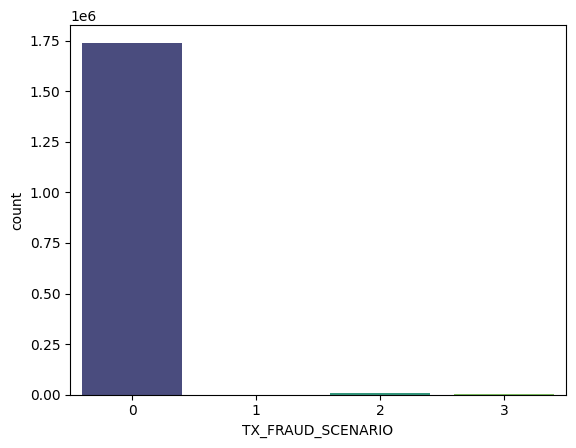

In [10]:
# Plot number of frquency for each senario
sns.countplot(data= merged_df, x='TX_FRAUD_SCENARIO',palette='viridis')

In [11]:
#count each senarion number of frquency
merged_df['TX_FRAUD_SCENARIO'].value_counts()

TX_FRAUD_SCENARIO
0    1739474
2       9077
3       4631
1        973
Name: count, dtype: int64

### Start Make Group by differnt senarios

In [10]:
# grop by TX_FRAUD_SCENARIO == 0
senario_zero = copy_merged_df[copy_merged_df['TX_FRAUD_SCENARIO'] == 0] 
senario_one = copy_merged_df[copy_merged_df['TX_FRAUD_SCENARIO'] == 1] 
senario_two = copy_merged_df[copy_merged_df['TX_FRAUD_SCENARIO'] == 2] 
senario_three = copy_merged_df[copy_merged_df['TX_FRAUD_SCENARIO'] == 3] 


## Non-Fraud senario

Text(0.5, 1.0, 'Distribution of mean_nb_tx_per_day for Scenario 0')

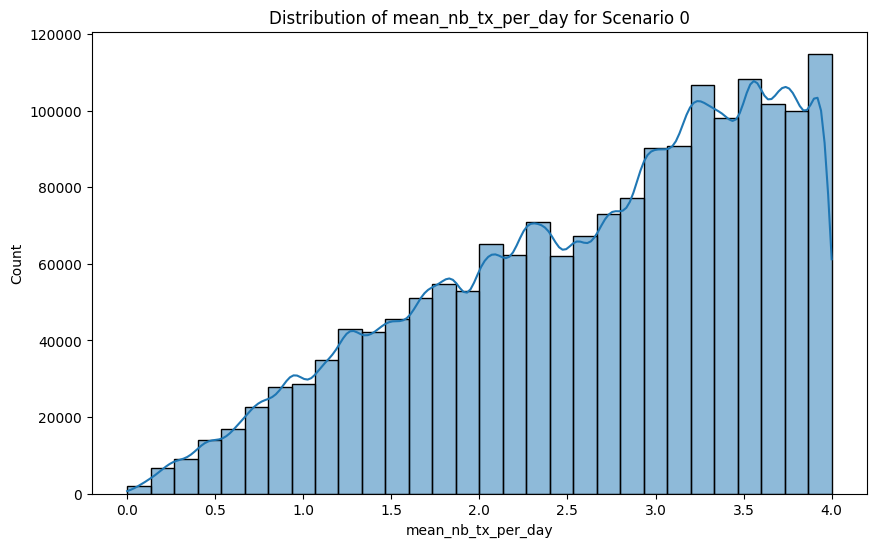

In [13]:
# see distribution of mean_nb_tx_per_day for senario 0
plt.figure(figsize=(10, 6))
sns.histplot(senario_zero['mean_nb_tx_per_day'], bins=30, kde=True)
plt.title('Distribution of mean_nb_tx_per_day for Scenario 0')

Text(0.5, 1.0, 'Distribution of mean_amount for Scenario 0')

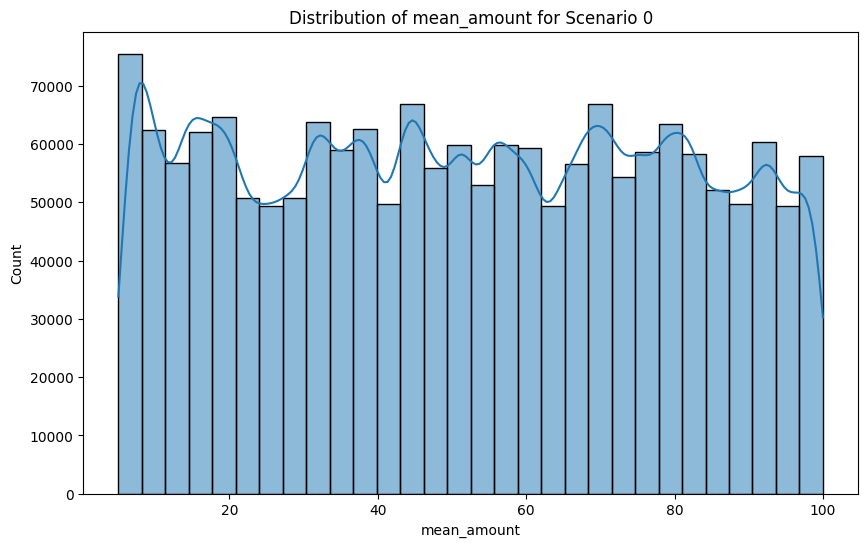

In [16]:
# see distribution of mean_amount for senario 0
plt.figure(figsize=(10,6))
sns.histplot(senario_zero["mean_amount"], bins=30, kde=True)
plt.title('Distribution of mean_amount for Scenario 0')

Text(0.5, 1.0, 'Distribution of std_amount for Scenario 0')

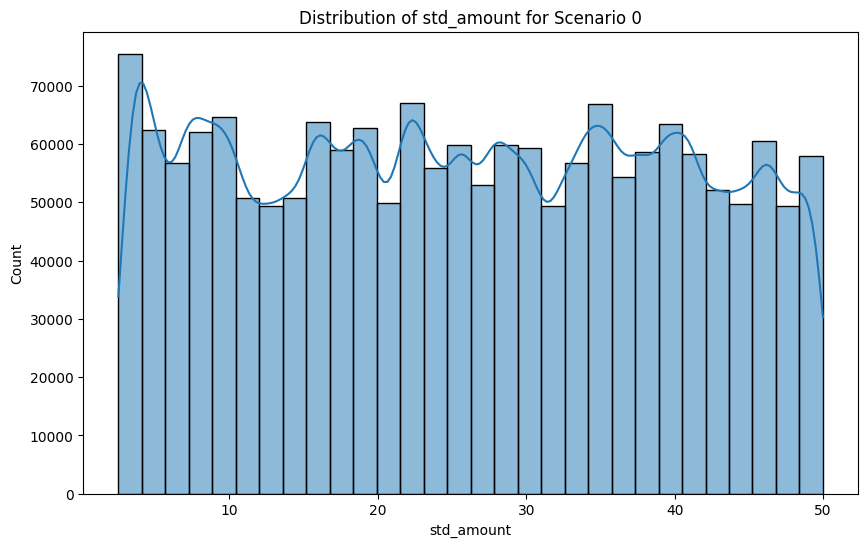

In [11]:
##see distribution of std_amount senario 0
plt.figure(figsize=(10,6))
sns.histplot(senario_zero["std_amount"], bins=30, kde=True)
plt.title('Distribution of std_amount for Scenario 0')

Text(0.5, 1.0, 'Distribution of mean_amount for Scenario 0')

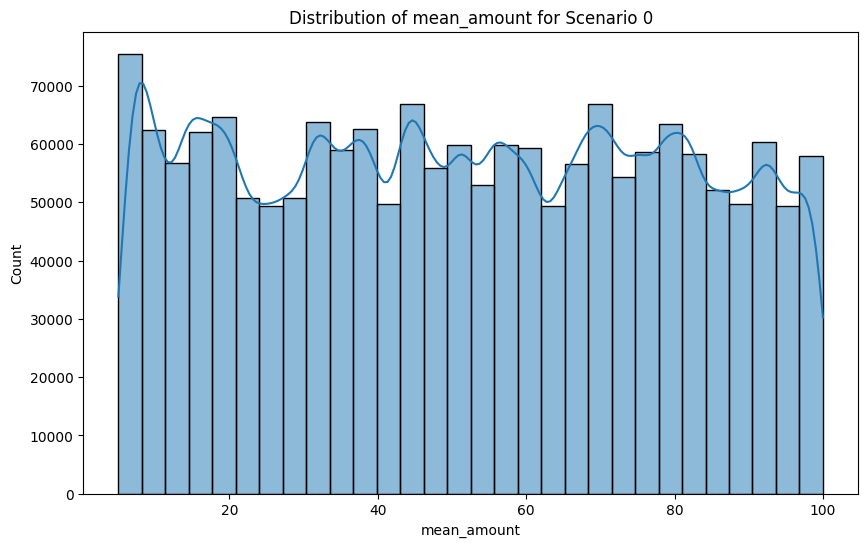

In [12]:
# see distribution of mean_amount for senario 0
plt.figure(figsize=(10,6))
sns.histplot(senario_zero["mean_amount"], bins=30, kde=True)
plt.title('Distribution of mean_amount for Scenario 0')

Text(0.5, 1.0, 'Distribution of TX_AMOUNT for Scenario 0')

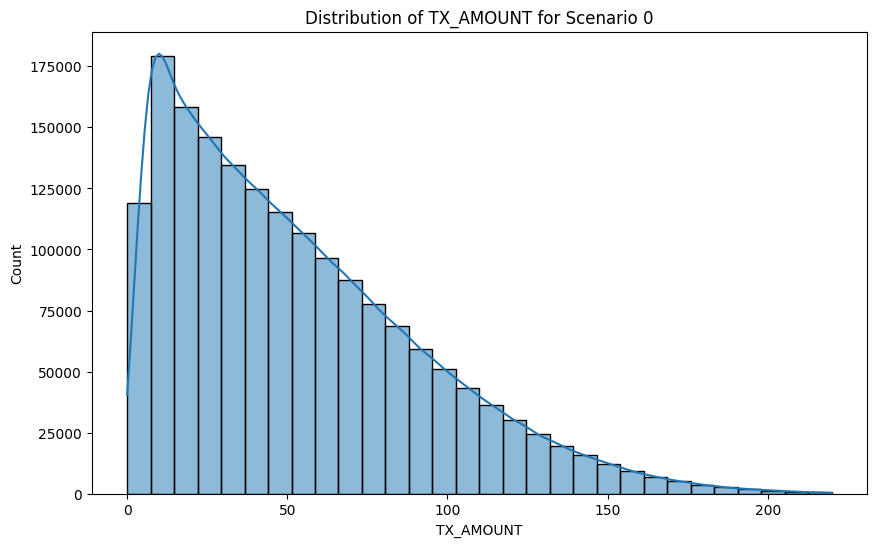

In [13]:
# see TX_AMOUNT distribution for senario 0
plt.figure(figsize=(10,6))
sns.histplot(senario_zero["TX_AMOUNT"], bins=30, kde=True)
plt.title('Distribution of TX_AMOUNT for Scenario 0')

Text(0.5, 1.0, 'Distribution of TX_AMOUNT for Scenario 0')

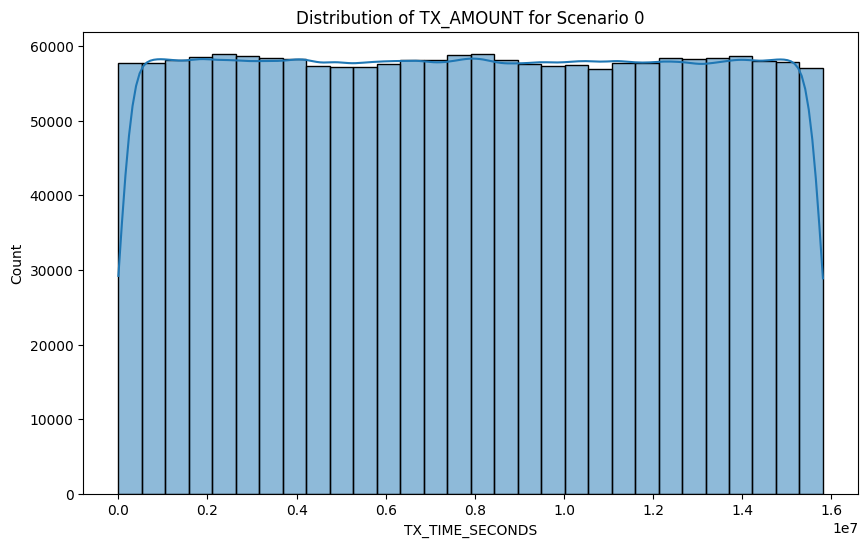

In [14]:
# see TX_TIME_SECONDS distribution for senario 0
plt.figure(figsize=(10,6))
sns.histplot(senario_zero["TX_TIME_SECONDS"], bins=30, kde=True)
plt.title('Distribution of TX_TIME_SECONDS for Scenario 0')

### Key Insight Question: Is there a strict amount-based threshold for Scenario 1? What is the minimum, maximum, and average transaction amount for Scenario 1 compared to Scenario 0?

Transaction Amount Statistics by Scenario:
                      min      max        mean         std    count
TX_FRAUD_SCENARIO                                                  
0                    0.00   219.98   52.977907   39.421733  1739474
1                  220.02   310.39  235.317071   14.639319      973
2                    0.02   234.69   53.808108   39.771214     9077
3                    0.10  2628.00  260.915148  204.142243     4631


/tmp/ipykernel_16790/490790435.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=copy_merged_df, x='TX_FRAUD_SCENARIO', y='TX_AMOUNT', palette='viridis')


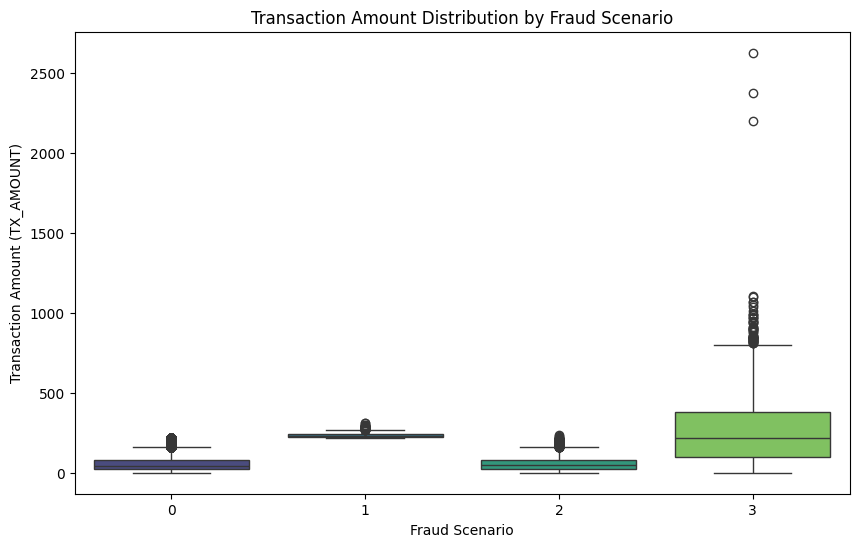

In [15]:
# Analyze the distribution of transaction amounts across scenarios
amount_stats = copy_merged_df.groupby('TX_FRAUD_SCENARIO')['TX_AMOUNT'].agg(['min', 'max', 'mean', 'std', 'count'])
print("Transaction Amount Statistics by Scenario:")
print(amount_stats)

# Visualize the distribution differences
plt.figure(figsize=(10, 6))
sns.boxplot(data=copy_merged_df, x='TX_FRAUD_SCENARIO', y='TX_AMOUNT', palette='viridis')
plt.title('Transaction Amount Distribution by Fraud Scenario')
plt.xlabel('Fraud Scenario')
plt.ylabel('Transaction Amount (TX_AMOUNT)')
plt.show()

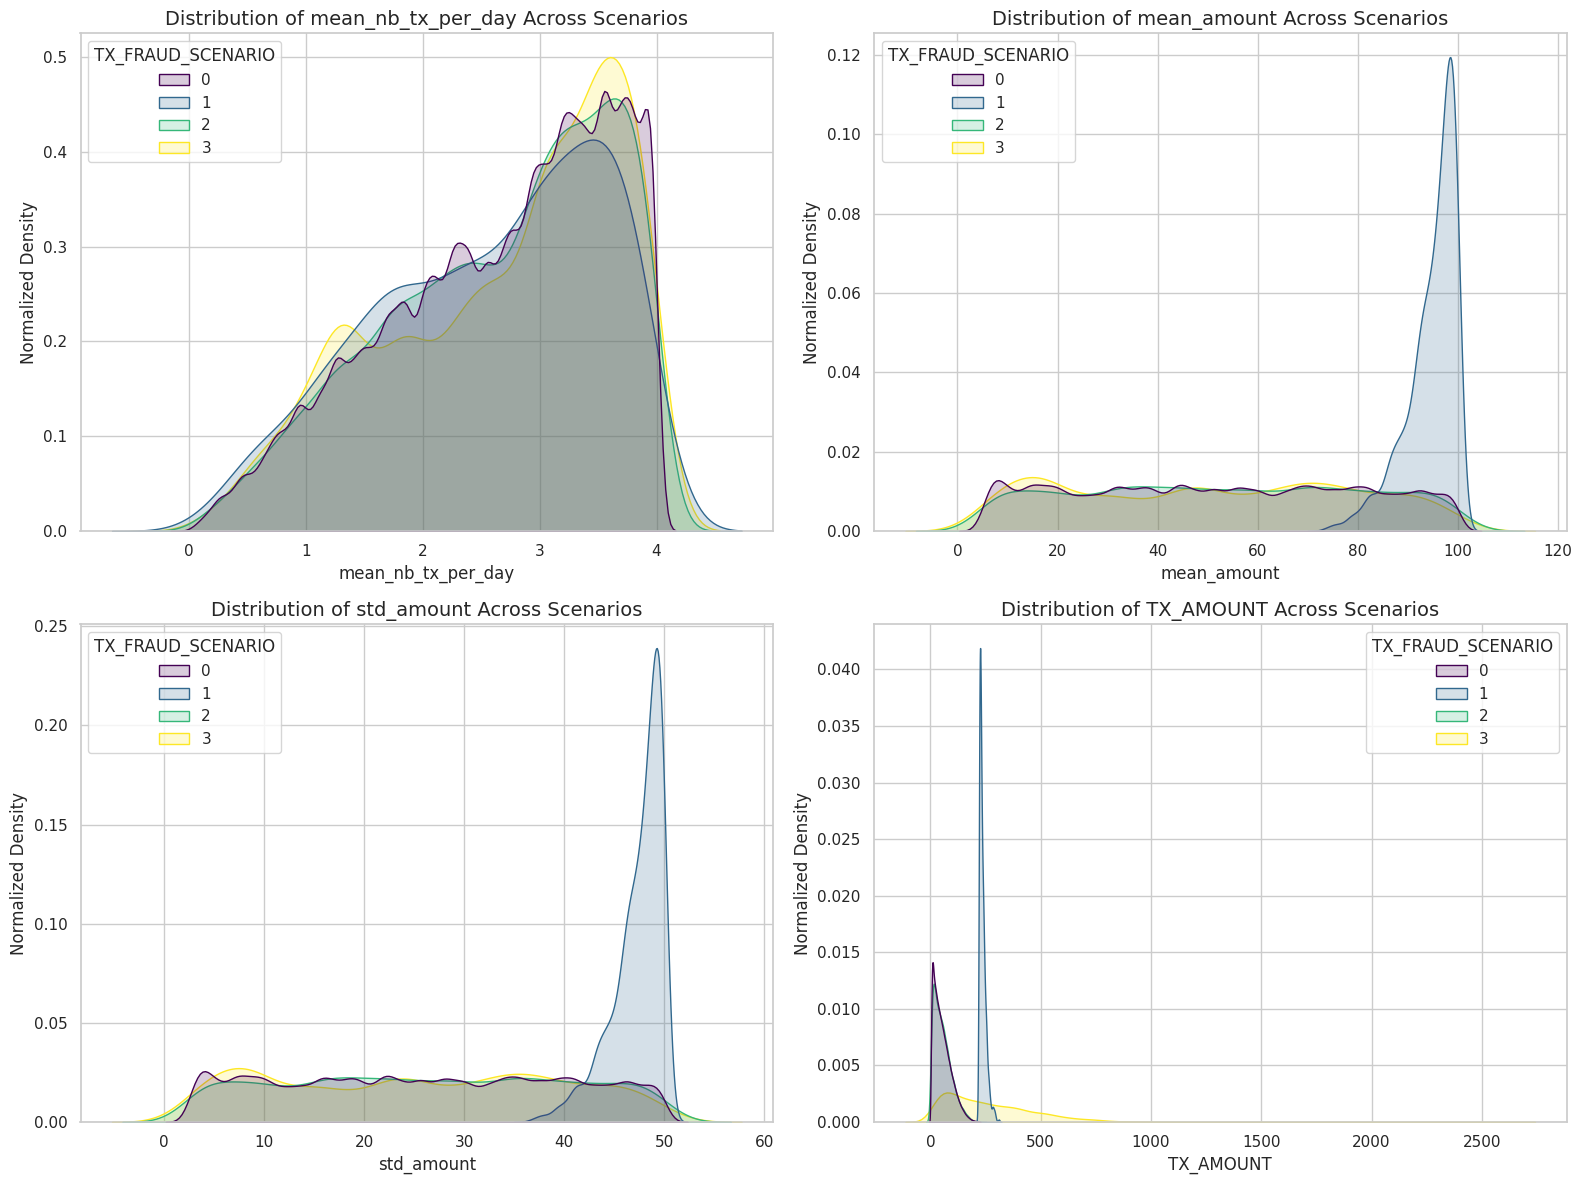

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for cleaner visuals
sns.set_theme(style="whitegrid")
# 1. Load terminal profiles to get x/y coordinates of the terminals
terminal_profiles = pd.read_csv('full dataset with brief/terminal_profiles.csv')


# The unique columns requested
cols_to_plot = ["mean_nb_tx_per_day", "mean_amount", "std_amount", "TX_AMOUNT"]

# Create a 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(cols_to_plot):
    ax = axes[idx]
    
    # We use common_norm=False because Scenario 0 has way more transactions.
    # This normalizes each scenario independently so we can visually compare their shapes.
    sns.kdeplot(
        data=copy_merged_df,
        x=col,
        hue='TX_FRAUD_SCENARIO',
        palette='viridis',
# 1. Feature Engineering: Convert seconds to Day and Hour variables

        fill=True,
        alpha=0.2,
        common_norm=False,
        ax=ax
    )
    ax.set_title(f'Distribution of {col} Across Scenarios', fontsize=14)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('Normalized Density', fontsize=12)

# Prevent overlap and render
plt.tight_layout()
plt.show()

=== AVERAGE DEVIATION FROM LEGITIMATE PROFILE (Scenario 0) ===
                   amount_deviation  spending_ratio  \
TX_FRAUD_SCENARIO                                     
0                          1.324003        1.026248   
1                        140.636974        2.491745   
2                          1.482717        1.024608   
3                        210.573107        5.184022   

                   pct_amount_deviation_change  \
TX_FRAUD_SCENARIO                                
0                                     0.000000   
1                                 10522.104779   
2                                    11.987462   
3                                 15804.278491   

                   spending_ratio_deviation_from_baseline  
TX_FRAUD_SCENARIO                                          
0                                                0.000000  
1                                                1.465497  
2                                               -0.001640  
3    

/tmp/ipykernel_16790/830044987.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=copy_merged_df, x='TX_FRAUD_SCENARIO', y='spending_ratio', palette='viridis')


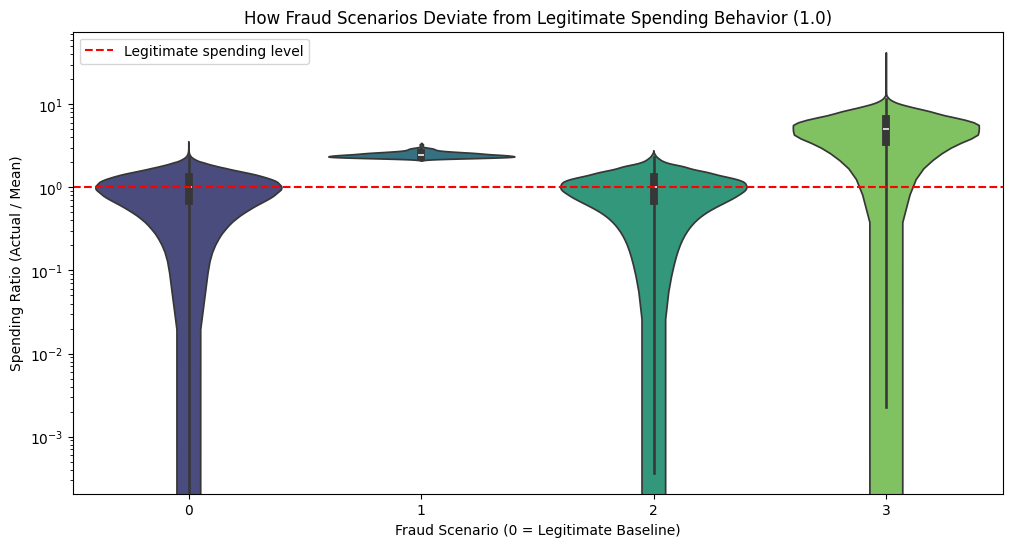

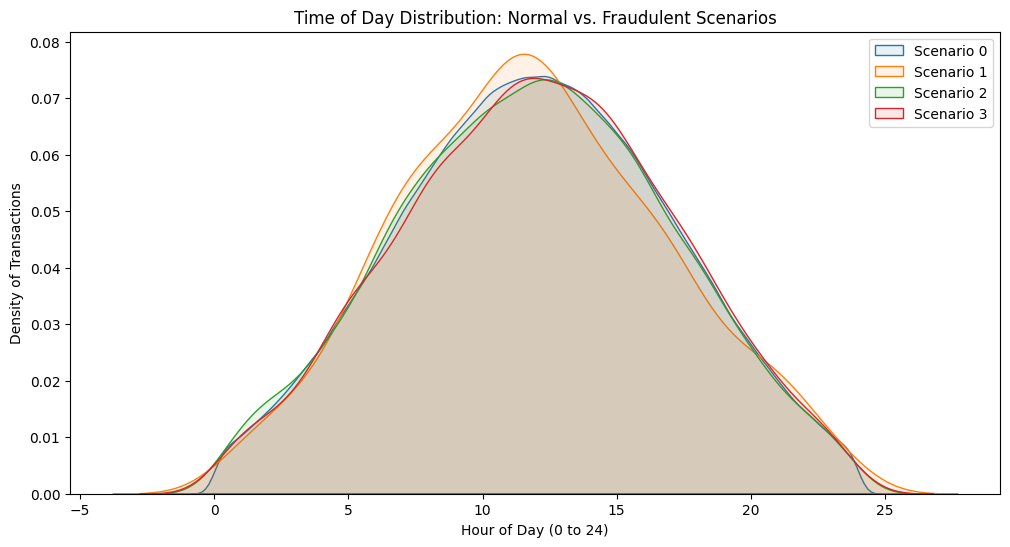

In [17]:
# 1. Feature Engineering: Deviations from Baseline
# Spending Ratio (1.0 = perfect match to customer average)
copy_merged_df['spending_ratio'] = copy_merged_df['TX_AMOUNT'] / copy_merged_df['mean_amount']
# Absolute deviation from customer's average spending
copy_merged_df['amount_deviation'] = copy_merged_df['TX_AMOUNT'] - copy_merged_df['mean_amount']
# Time of day in hours (0 to 23)
copy_merged_df['hour_of_day'] = (copy_merged_df['TX_TIME_SECONDS'] % 86400) / 3600

# 2. Measure Statistical Deviations
print("=== AVERAGE DEVIATION FROM LEGITIMATE PROFILE (Scenario 0) ===")
stats = copy_merged_df.groupby('TX_FRAUD_SCENARIO')[['amount_deviation', 'spending_ratio']].mean()
# Calculate relative change compared to Scenario 0
stats['pct_amount_deviation_change'] = ((stats['amount_deviation'] - stats.loc[0, 'amount_deviation']) / abs(stats.loc[0, 'amount_deviation'])) * 100
stats['spending_ratio_deviation_from_baseline'] = stats['spending_ratio'] - stats.loc[0, 'spending_ratio']
print(stats)

# 3. Visualize Spending Ratio Deviation
plt.figure(figsize=(12, 6))
sns.violinplot(data=copy_merged_df, x='TX_FRAUD_SCENARIO', y='spending_ratio', palette='viridis')
plt.axhline(1.0, color='red', linestyle='--', label='Legitimate spending level')
plt.title('How Fraud Scenarios Deviate from Legitimate Spending Behavior (1.0)')
plt.xlabel('Fraud Scenario (0 = Legitimate Baseline)')
plt.ylabel('Spending Ratio (Actual / Mean)')
plt.yscale('log')
plt.legend()
plt.show()

# 4. Visualize Time-of-Day Deviation
plt.figure(figsize=(12, 6))
for scenario in [0, 1, 2, 3]:
    subset = copy_merged_df[copy_merged_df['TX_FRAUD_SCENARIO'] == scenario]
    sns.kdeplot(subset['hour_of_day'], label=f'Scenario {scenario}', fill=True, alpha=0.1)
plt.title('Time of Day Distribution: Normal vs. Fraudulent Scenarios')
plt.xlabel('Hour of Day (0 to 24)')
plt.ylabel('Density of Transactions')
plt.legend()
plt.show()

=== GEOGRAPHICAL DISTANCE STATISTICS BY SCENARIO ===
                        min      mean       max       std
TX_FRAUD_SCENARIO                                        
0                  0.011552  3.309016  4.999990  1.187110
1                  0.078617  3.298300  4.998768  1.186210
2                  0.122872  3.298120  4.999470  1.202143
3                  0.092283  3.311219  4.999825  1.200173


/tmp/ipykernel_16790/2043370701.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=geo_df, x='TX_FRAUD_SCENARIO', y='customer_terminal_distance', palette='viridis')


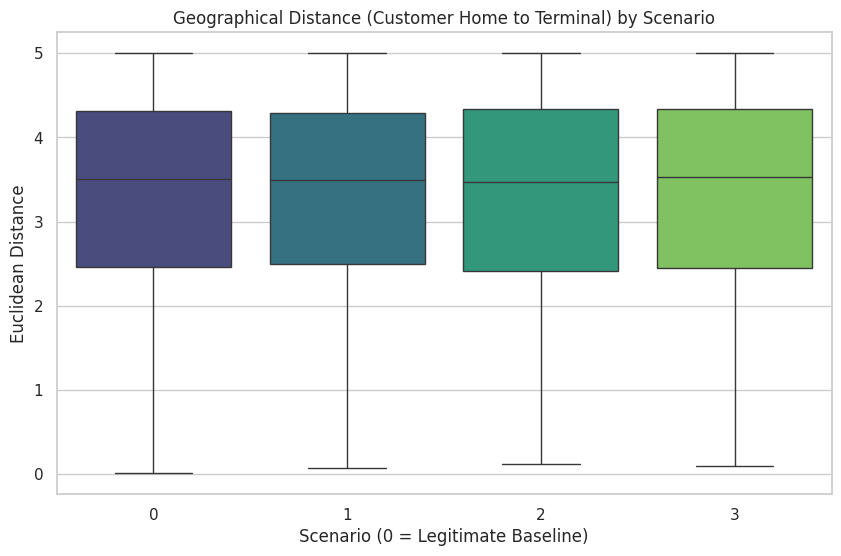

In [20]:
import numpy as np
# 1. Load terminal profiles to get x/y coordinates of the terminals
terminal_profiles = pd.read_csv('full dataset with brief/terminal_profiles.csv')

# 2. Merge terminal coordinates into your dataset
geo_df = pd.merge(copy_merged_df, terminal_profiles, on='TERMINAL_ID', how='inner')

# 3. Calculate the Euclidean distance between the customer's home and the terminal
geo_df['customer_terminal_distance'] = np.sqrt(
    (geo_df['x_customer_id'] - geo_df['x_terminal_id'])**2 + 
    (geo_df['y_customer_id'] - geo_df['y_terminal_id'])**2
)

# 4. Measure the statistics of distance across scenarios
print("=== GEOGRAPHICAL DISTANCE STATISTICS BY SCENARIO ===")
distance_stats = geo_df.groupby('TX_FRAUD_SCENARIO')['customer_terminal_distance'].agg(['min', 'mean', 'max', 'std'])
print(distance_stats)

# 5. Visualize the geographic deviation
plt.figure(figsize=(10, 6))
sns.boxplot(data=geo_df, x='TX_FRAUD_SCENARIO', y='customer_terminal_distance', palette='viridis')
plt.title('Geographical Distance (Customer Home to Terminal) by Scenario')
plt.xlabel('Scenario (0 = Legitimate Baseline)')
plt.ylabel('Euclidean Distance')
plt.show()

=== CHRONOLOGICAL PROGRESSION (DAYS) ===
                        min       mean         max        std
TX_FRAUD_SCENARIO                                            
0                  0.000359  91.430456  182.999965  52.856901
1                  0.428970  91.374822  182.469965  52.252737
2                  2.055984  98.103757  182.936123  49.658857
3                  1.042419  94.330387  182.935463  50.847472

=== TIME OF DAY DISTRIBUTION (HOURS) ===
                        min       mean        max       std
TX_FRAUD_SCENARIO                                          
0                  0.000278  12.000480  23.999722  5.052039
1                  0.007500  11.881649  23.905278  5.013517
2                  0.000833  11.924113  23.979722  5.094718
3                  0.005833  12.080444  23.994167  5.065165


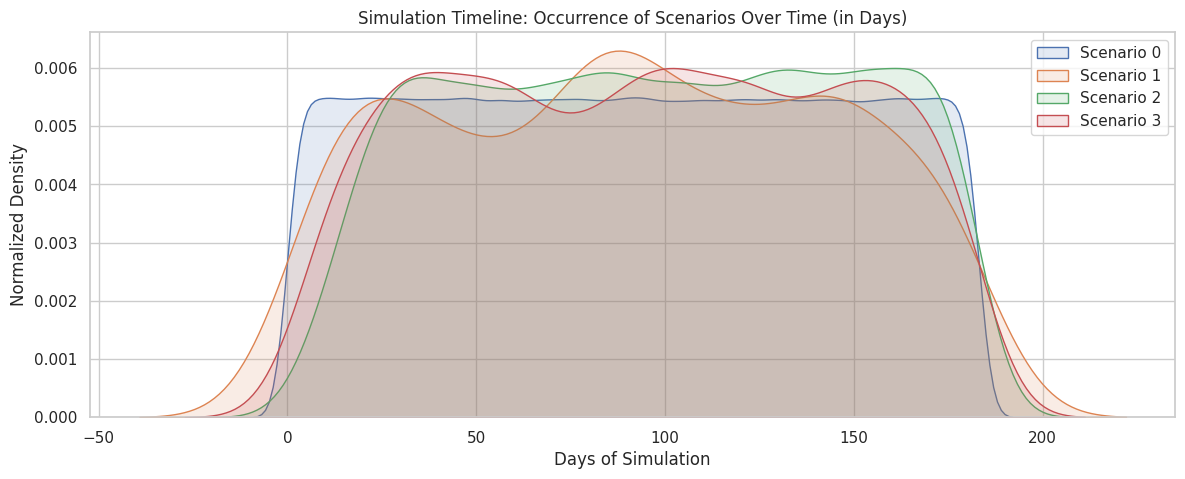

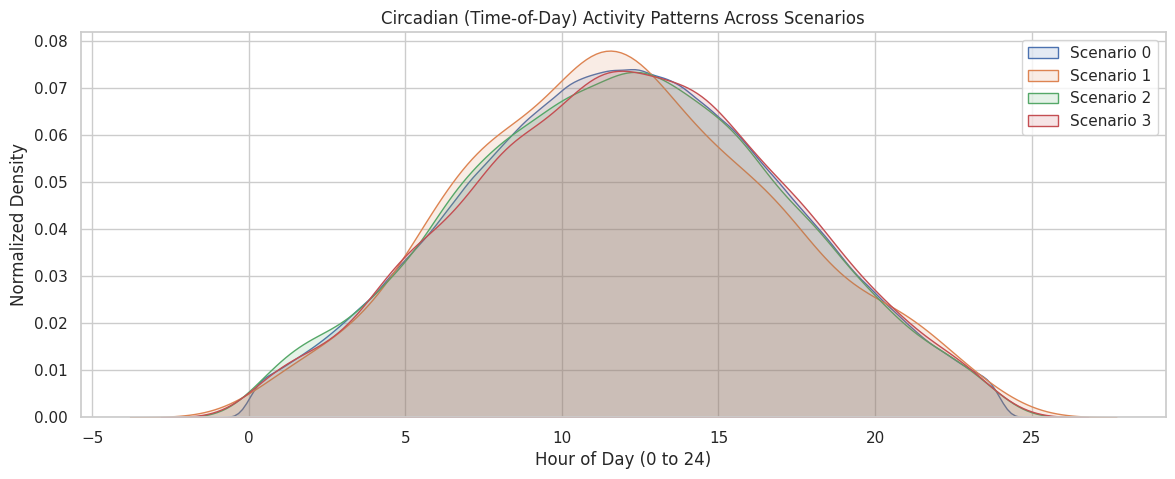

In [21]:
# 1. Feature Engineering: Convert seconds to Day and Hour variables
# Time of day in hours (0.0 to 24.0)
copy_merged_df['hour_of_day'] = (copy_merged_df['TX_TIME_SECONDS'] % 86400) / 3600
# Chronological days of the simulation
copy_merged_df['day_of_simulation'] = copy_merged_df['TX_TIME_SECONDS'] / 86400

# 2. Print Descriptive Statistics for Time Features
print("=== CHRONOLOGICAL PROGRESSION (DAYS) ===")
print(copy_merged_df.groupby('TX_FRAUD_SCENARIO')['day_of_simulation'].agg(['min', 'mean', 'max', 'std']))

print("\n=== TIME OF DAY DISTRIBUTION (HOURS) ===")
print(copy_merged_df.groupby('TX_FRAUD_SCENARIO')['hour_of_day'].agg(['min', 'mean', 'max', 'std']))

# 3. Plot 1: Chronological timeline (Day 0 to End)
plt.figure(figsize=(14, 5))
for scenario in [0, 1, 2, 3]:
    subset = copy_merged_df[copy_merged_df['TX_FRAUD_SCENARIO'] == scenario]
    sns.kdeplot(subset['day_of_simulation'], label=f'Scenario {scenario}', fill=True, alpha=0.15, common_norm=False)
plt.title('Simulation Timeline: Occurrence of Scenarios Over Time (in Days)')
plt.xlabel('Days of Simulation')
plt.ylabel('Normalized Density')
plt.legend()
plt.show()

# 4. Plot 2: Time of Day cycles (0 to 24 hours)
plt.figure(figsize=(14, 5))
for scenario in [0, 1, 2, 3]:
    subset = copy_merged_df[copy_merged_df['TX_FRAUD_SCENARIO'] == scenario]
    sns.kdeplot(subset['hour_of_day'], label=f'Scenario {scenario}', fill=True, alpha=0.15, common_norm=False)
plt.title('Circadian (Time-of-Day) Activity Patterns Across Scenarios')
plt.xlabel('Hour of Day (0 to 24)')
plt.ylabel('Normalized Density')
plt.legend()
plt.show()

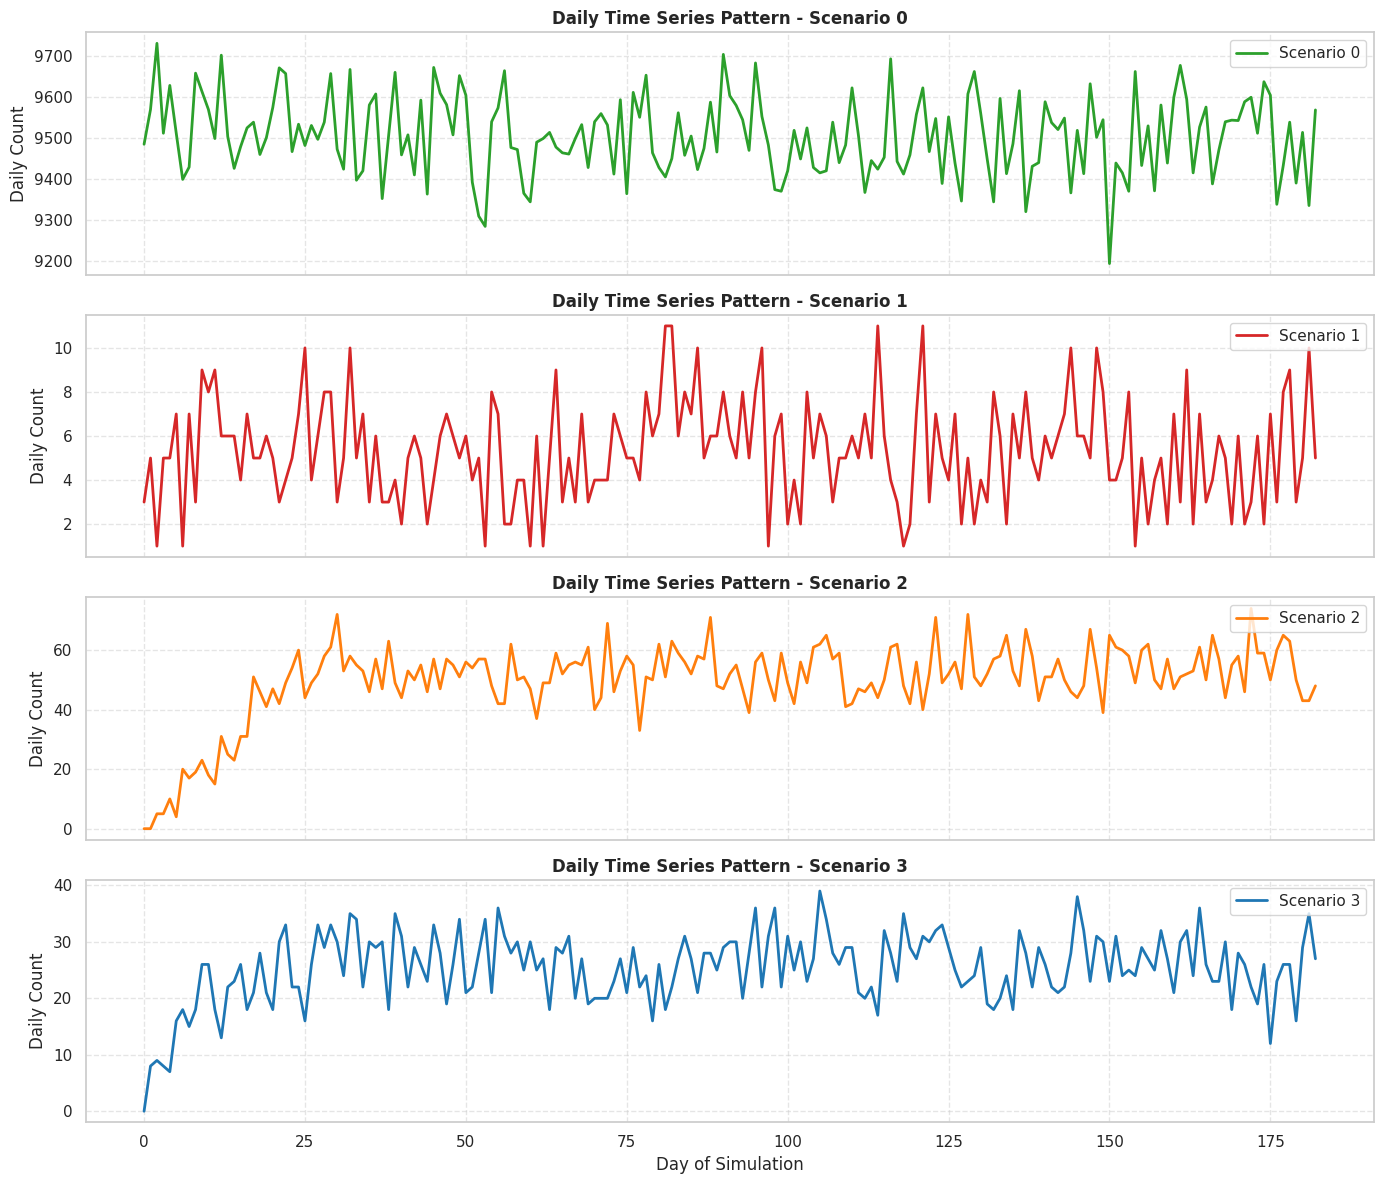

=== AVERAGE DAILY TRANSACTION VOLUME ===
Scenario 0    9505.32
Scenario 1       5.32
Scenario 2      49.60
Scenario 3      25.31
dtype: float64


In [22]:
# 1. Group by Day and Scenario, then calculate the daily transaction count
daily_counts = copy_merged_df.groupby(['TX_TIME_DAYS', 'TX_FRAUD_SCENARIO']).size().unstack(fill_value=0)

# Rename the columns for the plot legend
daily_counts.columns = [f'Scenario {col}' for col in daily_counts.columns]

# 2. Plotting the time series using a 4-row vertical grid
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# Different colors to distinguish scenarios
colors = ['#2ca02c', '#d62728', '#ff7f0e', '#1f77b4'] # Green for normal, red/orange/blue for fraud

for idx, col in enumerate(daily_counts.columns):
    ax = axes[idx]
    ax.plot(daily_counts.index, daily_counts[col], color=colors[idx], linewidth=2, label=col)
    ax.set_title(f'Daily Time Series Pattern - {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Daily Count')
    ax.legend(loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.5)

axes[-1].set_xlabel('Day of Simulation', fontsize=12)
plt.tight_layout()
plt.show()

# 3. Print average daily transaction volume for reference
print("=== AVERAGE DAILY TRANSACTION VOLUME ===")
print(daily_counts.mean().round(2))

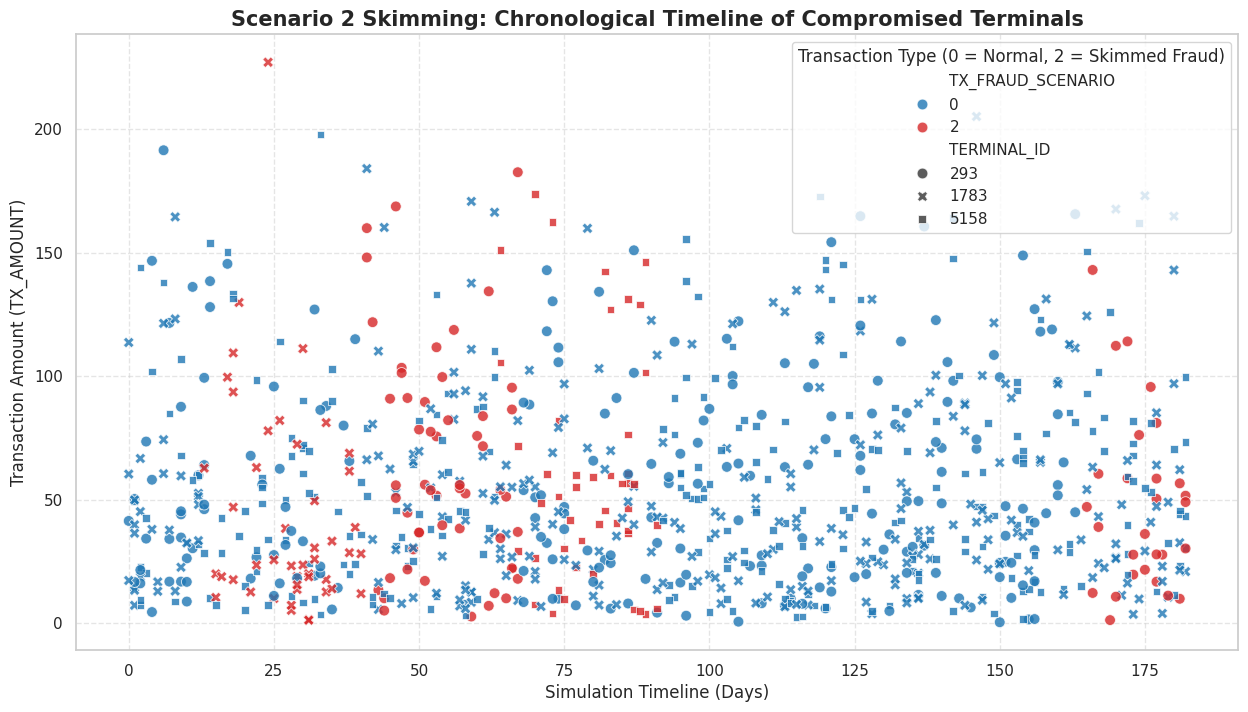

In [23]:
# 1. Identify which terminals were compromised under Scenario 2
compromised_terminal_ids = copy_merged_df[copy_merged_df['TX_FRAUD_SCENARIO'] == 2]['TERMINAL_ID'].unique()

# 2. Get the top 3 compromised terminals with the most transaction activity
top_3_compromised = copy_merged_df[copy_merged_df['TERMINAL_ID'].isin(compromised_terminal_ids)]['TERMINAL_ID'].value_counts().head(3).index

# 3. Filter data for just these 3 terminals
compromised_data = copy_merged_df[copy_merged_df['TERMINAL_ID'].isin(top_3_compromised)].copy()

# Ensure we plot Scenario 0 and Scenario 2 clearly
compromised_data = compromised_data[compromised_data['TX_FRAUD_SCENARIO'].isin([0, 2])]

# 4. Plot the time-series transaction scatter plot
plt.figure(figsize=(15, 8))
sns.scatterplot(
    data=compromised_data,
    x='TX_TIME_DAYS',
    y='TX_AMOUNT',
    hue='TX_FRAUD_SCENARIO',
    style='TERMINAL_ID',
    palette={0: '#1f77b4', 2: '#d62728'}, # Blue for normal, Red for fraud
    alpha=0.8,
    s=60
)

# Draw a vertical span or line helper to show the 28-day compromise window
plt.title('Scenario 2 Skimming: Chronological Timeline of Compromised Terminals', fontsize=15, fontweight='bold')
plt.xlabel('Simulation Timeline (Days)', fontsize=12)
plt.ylabel('Transaction Amount (TX_AMOUNT)', fontsize=12)
plt.legend(title='Transaction Type (0 = Normal, 2 = Skimmed Fraud)', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 📊 Fraud Scenario Analysis Report

## Executive Summary
An analysis of transaction behavior was conducted across three distinct simulated fraud scenarios against a legitimate baseline (Scenario 0). The investigation evaluated transaction volumes, deviations from historical customer profiles, and timeline distributions to map out the unique operational fingerprint of each fraudulent profile. 

---

## 🔍 Detailed Scenario Profiles

### 🟢 Scenario 0: Legitimate Baseline (Normal Behavior)
* **Transaction Amount:** Consistently low and tightly bound, primarily remaining under **$100**.
* **Spending Deviation:** Sits cleanly at a **1.0 spending ratio** (Actual / Mean), indicating customers are spending exactly what their historical metrics predict.
* **Timeline Distribution:** Shows a stable, high-frequency density across the entire 180-day simulation timeframe without anomalous spikes or sudden ramp-ups.
* **Classification:** Standard, predictable consumer purchasing patterns.

### 🔵 Scenario 1: The "Fixed-Threshold" Programmatic Fraud
* **Transaction Amount:** Displays an incredibly rigid, narrow distribution tightly bound right around **$250**. The variance is nearly non-existent.
* **Spending Deviation:** The spending ratio scales predictably relative to the victim's card history, showing up as a distinct, flat band on deviation charts.
* **Timeline Distribution:** Occurs at a very low but persistent frequency (1 to 11 incidents daily) throughout the entire timeline.
* **Fraud Behavior:** Mimics **automated card-testing or programmatic exploits** targeting a specific financial threshold known to bypass automated instant-block rules.

### 🟢 Scenario 2: The "Low-Profile/Stealth" Merchant Fraud
* **Transaction Amount:** Completely identical to normal behavior, with amounts usually falling well below **$100**. 
* **Spending Deviation:** Maintains a perfect **1.0 spending ratio**, making it completely indistinguishable from legitimate behavior at an individual transaction level.
* **Timeline Distribution:** **This is the primary indicator.** It starts at zero on Day 0 and steadily ramps up over a 25-day period before flattening into a high-volume plateau (~40–60 incidents per day).
* **Fraud Behavior:** Classic **compromised terminal or rogue merchant fraud**. Because individual transactions appear safe, detection relies entirely on identifying point-of-sale volume anomalies or aggregated terminal risk patterns over time.

### 🪟 Scenario 3: The "Whale/Account-Draining" Identity Theft
* **Transaction Amount:** Volatile and massive. While the bulk sits between $100 and $500, it features a heavy tail of extreme outliers reaching up to **$2,500+**.
* **Spending Deviation:** Fully detaches from historical profiles, averaging **5x to 10x higher** than the victim’s typical `mean_amount`.
* **Timeline Distribution:** Features an initial 20-day ramp-up phase before stabilizing into a steady frequency of 20–35 daily occurrences.
* **Fraud Behavior:** Represents aggressive **identity theft or card-cloning**. The fraudster ignores normal spending patterns, prioritizing maximizing immediate cash-out value before the account is permanently locked by the cardholder.

---

## 🛠️ Feature Engineering Recommendations

To effectively catch these anomalies using Machine Learning (e.g., XGBoost, LightGBM), the following specialized features should be integrated into your pipeline:

| Fraud Scenario | Target Indicator | Recommended Feature Strategy |
| :--- | :--- | :--- |
| **Scenario 1** | Rigid transaction values | Binned boolean flags targeting specific absolute values (e.g., `is_near_250_usd`). |
| **Scenario 2** | Terminal-based volume shifts over time | Rolling terminal risk windows (e.g., `terminal_fraud_rate_7d`, `terminal_velocity_30d`). |
| **Scenario 3** | Severe profile deviation | Behavioral ratio metrics (e.g., `TX_AMOUNT / mean_amount` and `TX_AMOUNT / std_amount`). |